# Proyecto 2 - Modelo de Regresión Logística

## Configuración

**Librerías**

In [22]:
import pandas as pd
import numpy as np
from scipy.stats import uniform
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix, classification_report

**Parámetros**

In [7]:
base_de_datos = 'DB_LIMPIA (1).csv'

## Preprocesamiento

In [8]:
df = pd.read_csv(base_de_datos, sep = ";", index_col = 0)
df.columns

Index(['VIC_SEXO', 'VIC_EDAD', 'TOTAL_HIJOS', 'VIC_ESCOLARIDAD', 'VIC_EST_CIV',
       'VIC_GRUPET', 'VIC_TRABAJA', 'VIC_DISC', 'VIC_REL_AGR',
       'OTRAS_VICTIMAS', 'HEC_DIA', 'HEC_MES', 'HEC_ANO', 'HEC_AREA',
       'HEC_TIPAGRE', 'INST_DONDE_DENUNCIO', 'AGR_SEXO', 'AGR_EDAD',
       'AGR_ESCOLARIDAD', 'AGR_EST_CIV', 'AGR_GRUPET', 'AGR_TRABAJA',
       'INST_DENUN_HECHO', 'MEDIDAS_SEGURIDAD'],
      dtype='object')

In [10]:
# Se crea el DataFrame de víctimas.
df_victimas = df.loc[:, ['VIC_SEXO', 'VIC_EDAD', 'VIC_ESCOLARIDAD','VIC_EST_CIV', 'VIC_GRUPET', 'VIC_TRABAJA']]
df_victimas.columns = ['SEXO', 'EDAD', 'ESCOLARIDAD', 'ESTADO_CIVIL','GRUPO_ETNICO', 'TRABAJA']
df_victimas['ETIQUETA'] = 'VICTIMA'

# Se crea el DataFrame de agresores.
df_agresores = df.loc[:, ['AGR_SEXO', 'AGR_EDAD', 'AGR_ESCOLARIDAD','AGR_EST_CIV', 'AGR_GRUPET', 'AGR_TRABAJA']]
df_agresores.columns = ['SEXO', 'EDAD', 'ESCOLARIDAD', 'ESTADO_CIVIL','GRUPO_ETNICO', 'TRABAJA']
df_agresores['ETIQUETA'] = 'AGRESOR'

# Se crea el DataFrame de cluster.
df_classification = pd.concat([df_victimas, df_agresores])
df_classification.head(5)

,SEXO,EDAD,ESCOLARIDAD,ESTADO_CIVIL,GRUPO_ETNICO,TRABAJA,ETIQUETA
0,Mujeres,11,Primaria,Desconocido,Ladino,No,VICTIMA
1,Hombres,4,Desconocido,Desconocido,Ladino,Desconocido,VICTIMA
2,Hombres,11,Primaria,Desconocido,Ladino,No,VICTIMA
3,Mujeres,6,Desconocido,Desconocido,Ladino,Desconocido,VICTIMA
4,Hombres,11,Primaria,Desconocido,Ladino,No,VICTIMA


In [12]:
len(df_classification)

717996

In [11]:
counts = df_classification['ETIQUETA'].value_counts()
props  = df_classification['ETIQUETA'].value_counts(normalize=True) * 100

print("=== Distribución y proporción ===")
print(pd.DataFrame({'Cantidad': counts, 'Proporción (%)': props.round(2)}))

=== Distribución y proporción ===
          Cantidad  Proporción (%)
ETIQUETA                          
VICTIMA     358998            50.0
AGRESOR     358998            50.0


In [19]:
# Se seleccionan las columnas categóricas y numéricas.
cat_cols = ["SEXO", "ESCOLARIDAD", "ESTADO_CIVIL", "GRUPO_ETNICO", "TRABAJA"]
num_cols = ["EDAD"]

# Las columnas categóricas se transforman usando un OneHotEncoder.
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
df_classification_cat = ohe.fit_transform(df_classification[cat_cols])

# Se estandarizan las columnas numéricas.
scaler = StandardScaler()
df_classification_num = scaler.fit_transform(df_classification[num_cols])

# Se unen las variables transformadas en una matriz.
X = np.hstack([df_classification_num, df_classification_cat])

# Se crea el DataFrame ya con las variables transformadas.
feature_names = np.concatenate([num_cols, ohe.get_feature_names_out(cat_cols)])
df_classification_agg = pd.DataFrame(X, columns = feature_names, index = df_classification.index)
df_classification_agg['ETIQUETA'] = df_classification['ETIQUETA']
df_classification_agg.head()

,EDAD,SEXO_Hombres,SEXO_Mujeres,ESCOLARIDAD_Básico,ESCOLARIDAD_Desconocido,ESCOLARIDAD_Diversificado,ESCOLARIDAD_Ninguna,ESCOLARIDAD_Primaria,ESCOLARIDAD_Universidad,ESTADO_CIVIL_Casado,ESTADO_CIVIL_Desconocido,ESTADO_CIVIL_Otro,ESTADO_CIVIL_Soltero,ESTADO_CIVIL_Unido,ESTADO_CIVIL_Viudo,GRUPO_ETNICO_Desconocido,GRUPO_ETNICO_Garifuna,GRUPO_ETNICO_Ladino,GRUPO_ETNICO_Maya,GRUPO_ETNICO_Otro,GRUPO_ETNICO_Xinca,TRABAJA_Desconocido,TRABAJA_No,TRABAJA_Si,ETIQUETA
0,-1.585821,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,VICTIMA
1,-2.112327,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,VICTIMA
2,-1.585821,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,VICTIMA
3,-1.961897,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,VICTIMA
4,-1.585821,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,VICTIMA


## Elaboración del Modelo

In [21]:
# ── 1. Separar features y target ──────────────────────────────────────────────
X = df_classification_agg.drop(columns=['ETIQUETA'])
y = df_classification_agg['ETIQUETA']

# ── 2. Muestra estratificada del 25% para el RandomizedSearch ─────────────────
# stratify=y garantiza que la proporción 50/50 se mantenga en la muestra
X_sample, _, y_sample, _ = train_test_split(
    X, y,
    test_size=0.75,        # nos quedamos con el 25%
    stratify=y,
    random_state=42
)

# ── 3. Split del dataset COMPLETO para entrenar el modelo final ───────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,        # 80% train / 20% test
    stratify=y,
    random_state=42
)

print(f"Muestra para búsqueda:  {X_sample.shape[0]:,} registros")
print(f"Train (modelo final):   {X_train.shape[0]:,} registros")
print(f"Test  (evaluación):     {X_test.shape[0]:,} registros")

# Verificar que el balance se mantiene
print(f"\nBalance en muestra: {y_sample.value_counts(normalize=True).to_dict()}")
print(f"Balance en train:   {y_train.value_counts(normalize=True).to_dict()}")

Muestra para búsqueda:  179,499 registros
Train (modelo final):   574,396 registros
Test  (evaluación):     143,600 registros

Balance en muestra: {'VICTIMA': 0.5000027855308387, 'AGRESOR': 0.4999972144691614}
Balance en train:   {'VICTIMA': 0.5, 'AGRESOR': 0.5}


In [23]:
# ── 4. RandomizedSearch sobre la MUESTRA ─────────────────────────────────────
param_dist = {
    'C':            uniform(0.001, 10),
    'penalty':      ['l1', 'l2', 'elasticnet'],
    'solver':       ['saga'],
    'class_weight': ['balanced', None],
    'l1_ratio':     uniform(0, 1),      # solo aplica a elasticnet
    'max_iter':     [500, 1000, 2000]
}

search = RandomizedSearchCV(
    LogisticRegression(),
    param_distributions=param_dist,
    n_iter=30,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_sample, y_sample)   # ← sobre la muestra

print("Mejores hiperparámetros:", search.best_params_)
print(f"Recall (CV muestra):    {search.best_score_:.4f}")

# ── 5. Entrenar modelo final con mejores hiperparámetros sobre TODO el train ──
best_model = LogisticRegression(**search.best_params_)
best_model.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


Mejores hiperparámetros: {'C': np.float64(3.746401188473625), 'class_weight': 'balanced', 'l1_ratio': np.float64(0.1834347898661638), 'max_iter': 500, 'penalty': 'l1', 'solver': 'saga'}
Recall (CV muestra):    nan


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


LogisticRegression(C=np.float64(3.746401188473625), class_weight='balanced',
                   l1_ratio=np.float64(0.1834347898661638), max_iter=500,
                   penalty='l1', solver='saga')

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Víctima       0.90      0.88      0.89     71800
     Agresor       0.88      0.90      0.89     71800

    accuracy                           0.89    143600
   macro avg       0.89      0.89      0.89    143600
weighted avg       0.89      0.89      0.89    143600



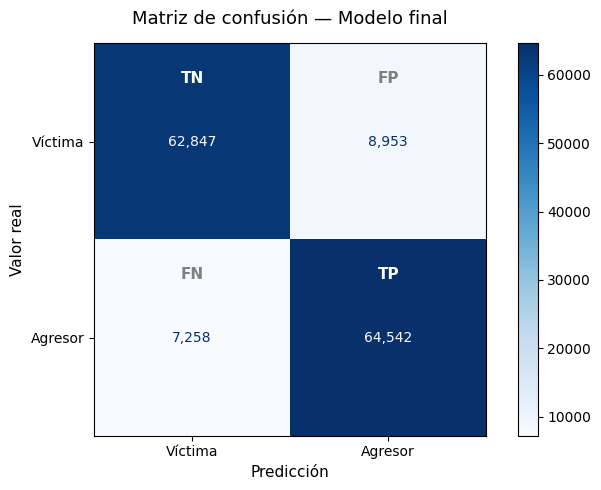


── Métricas clave ──────────────────────────────────────
  Recall (sensibilidad):  0.8989  ← minimiza falsos negativos
  Precisión:              0.8782
  Falsos negativos (FN):  7,258  ← agresores clasificados como víctimas
  Falsos positivos (FP):  8,953  ← víctimas clasificadas como agresores


In [25]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# ── 6. Predicciones sobre el test set ────────────────────────────────────────
y_pred = best_model.predict(X_test)

# ── 7. Classification Report ──────────────────────────────────────────────────
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Víctima', 'Agresor']))

# ── 8. Matriz de confusión ────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Víctima', 'Agresor']
)
disp.plot(ax=ax, cmap='Blues', values_format=',.0f')

# Anotaciones de TP / TN / FP / FN
labels = [
    ('TN', 0, 0), ('FP', 0, 1),
    ('FN', 1, 0), ('TP', 1, 1)
]
for name, row, col in labels:
    ax.text(
        col, row - 0.32,
        name,
        ha='center', va='center',
        fontsize=11, fontweight='bold',
        color='white' if name in ('TP', 'TN') else 'gray'
    )

ax.set_title('Matriz de confusión — Modelo final', fontsize=13, pad=14)
ax.set_xlabel('Predicción', fontsize=11)
ax.set_ylabel('Valor real', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 9. Métricas clave resumidas ───────────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()

print("\n── Métricas clave ──────────────────────────────────────")
print(f"  Recall (sensibilidad):  {tp / (tp + fn):.4f}  ← minimiza falsos negativos")
print(f"  Precisión:              {tp / (tp + fp):.4f}")
print(f"  Falsos negativos (FN):  {fn:,}  ← agresores clasificados como víctimas")
print(f"  Falsos positivos (FP):  {fp:,}  ← víctimas clasificadas como agresores")